# ChatGPT Camera Reasoning Loop

Workflow:
1. Copy `.env.example` to `.env` in the project root and fill in your `OPENAI_API_KEY`.
2. Run **Setup** and **Initialize** cells once.
3. Display the current screenshot and prompt (optional — just for visibility).
4. Run the **Ask ChatGPT** cell — it sends the prompt + screenshot to the OpenAI API and applies the returned action automatically.
5. Repeat step 4 until ChatGPT returns `STOP`.

In [1]:
import sys, os
# Add project root so `camera_reasoning` is importable when running from notebooks/
sys.path.insert(0, os.path.abspath('..'))

from camera_reasoning import CameraReasoningSession
from IPython.display import Image, display

## Initialize Session
Edit the paths and parameters below to match your data.

In [2]:
session = CameraReasoningSession(
    raw_path="../data/foot_256x256x256_uint8.raw",
    dimensions=(256, 256, 256),
    scalar_type="uint8",
    isovalue=80,
    output_dir="../output",
    target_description=(
        "Top view of the foot bones. Big toe on the right, little toe on the left, toes near the bottom, ankle/heel region near the top."
    ),
    target_image_path="../data/target.png",  # optional
    # simple_spatial_knowledge_path="../data/simple_foot_spatial_spec.json",  # optional spatial grounding
)

session.initialize()
session.render_and_save()
session.write_llm_prompt()

Scene initialized. Isovalue=80, dims=(256, 256, 256).


'You are ChatGPT, acting as a camera-reasoning assistant for a 3D VTK scene.\n\nYour job is to compare the current render with the target view description and\nchoose exactly one next camera action.\n\nRules:\n- You are NOT allowed to invent raw camera coordinates.\n- You are NOT allowed to output arbitrary angles.\n- You are NOT allowed to generate VTK code.\n- You MUST choose exactly one action from the allowed action list below.\n\nTarget view:\nTop view of the foot bones. Big toe on the right, little toe on the left, toes near the bottom, ankle/heel region near the top.\n\nCurrent render screenshot:\n../output/screenshots/latest.png\nTarget image: ../data/target.png\n\nCurrent camera:\n  position:       [142.426, 118.625, 889.035]\n  focal_point:    [142.426, 118.625, 121.945]\n  view_up:        [0.000, 1.000, 0.000]\n  view_angle:     30.00\n  clipping_range: [524.101, 1074.813]\n  distance:       767.090\n\nAction history:\n  (none yet)\n\nAllowed actions:\n  - AZIMUTH_LEFT_COARS

## View Current Screenshot and Prompt

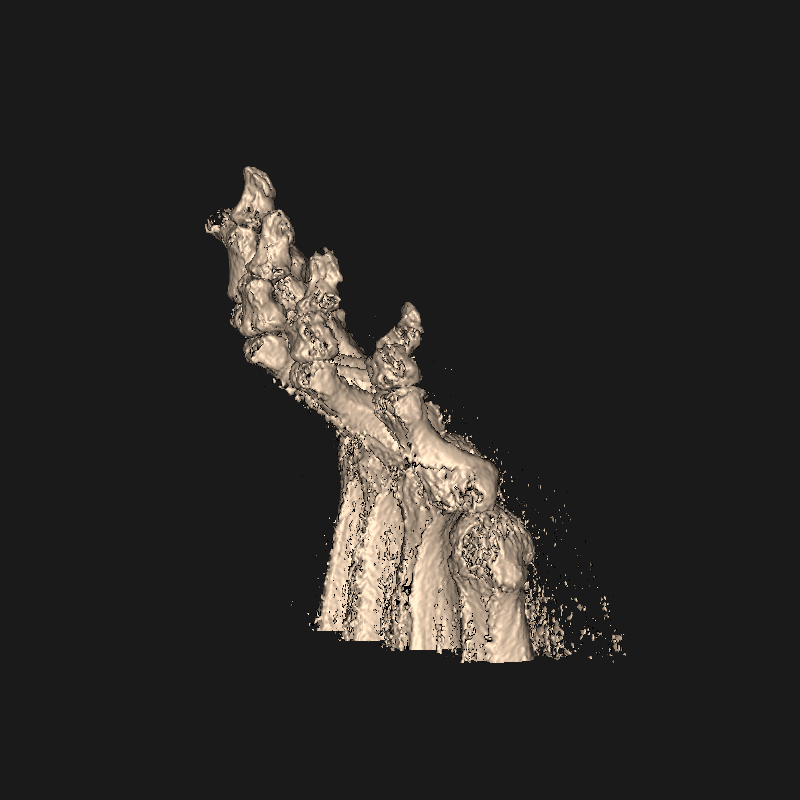

You are ChatGPT, acting as a camera-reasoning assistant for a 3D VTK scene.

Your job is to compare the current render with the target view description and
choose exactly one next camera action.

Rules:
- You are NOT allowed to invent raw camera coordinates.
- You are NOT allowed to output arbitrary angles.
- You are NOT allowed to generate VTK code.
- You MUST choose exactly one action from the allowed action list below.

Target view:
Top view of the foot bones. Big toe on the right, little toe on the left, toes near the bottom, ankle/heel region near the top.

Current render screenshot:
../output/screenshots/latest.png
Target image: ../data/target.png

Current camera:
  position:       [142.426, 118.625, 889.035]
  focal_point:    [142.426, 118.625, 121.945]
  view_up:        [0.000, 1.000, 0.000]
  view_angle:     30.00
  clipping_range: [524.101, 1074.813]
  distance:       767.090

Action history:
  (none yet)

Allowed actions:
  - AZIMUTH_LEFT_COARSE: orbit camera 45 degrees left

In [3]:
display(Image("../output/screenshots/latest.png"))
print(open("../output/llm_prompt.txt").read())

## Ask ChatGPT

Two ways to use this:

- **Quick loop** (below): auto-generates the prompt from the current camera state and applies whatever action comes back. Good for just running the loop.
- **Prompt experimentation** (further down): lets you edit the prompt text yourself before sending it, and inspect the reply before deciding whether to apply it. Good for testing prompt/reasoning changes.

In [4]:
# session.ask_chatgpt_and_process()

# display(Image("../output/screenshots/latest.png"))
# print(open("../output/llm_prompt.txt").read())

## Run Multiple Iterations

Runs the quick loop repeatedly instead of re-running the cell above by hand. Stops early if `STOP` comes back.

/Users/chulu/Documents/llm-vis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[image_view_matcher] Loading 'openai/clip-vit-base-patch32' on cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[image_view_matcher] Encoded Distal: Distal.png
[image_view_matcher] Encoded Dorsal: Dorsal.png
[image_view_matcher] Encoded Lateral: Lateral.png
[image_view_matcher] Encoded Medial: Medial.png
[image_view_matcher] Encoded from_vtk: Distal.png
[image_view_matcher] Encoded from_vtk: Dorsal.png
[image_view_matcher] Encoded from_vtk: DorsalDistal.png
[image_view_matcher] Encoded from_vtk: DorsalLateral.png
[image_view_matcher] Encoded from_vtk: DorsalMedial.png
[image_view_matcher] Encoded from_vtk: DorsalProximal.png
[image_view_matcher] Encoded from_vtk: Lateral.png
[image_view_matcher] Encoded from_vtk: LateralDistal.png
[image_view_matcher] Encoded from_vtk: LateralProximal.png
[image_view_matcher] Encoded from_vtk: Medial.png
[image_view_matcher] Encoded from_vtk: MedialDistal.png
[image_view_matcher] Encoded from_vtk: MedialProximal.png
[image_view_matcher] Encoded from_vtk: Plantar.png
[image_view_matcher] Encoded from_vtk: PlantarDistal.png
[image_view_matcher] Encoded from_vtk: P

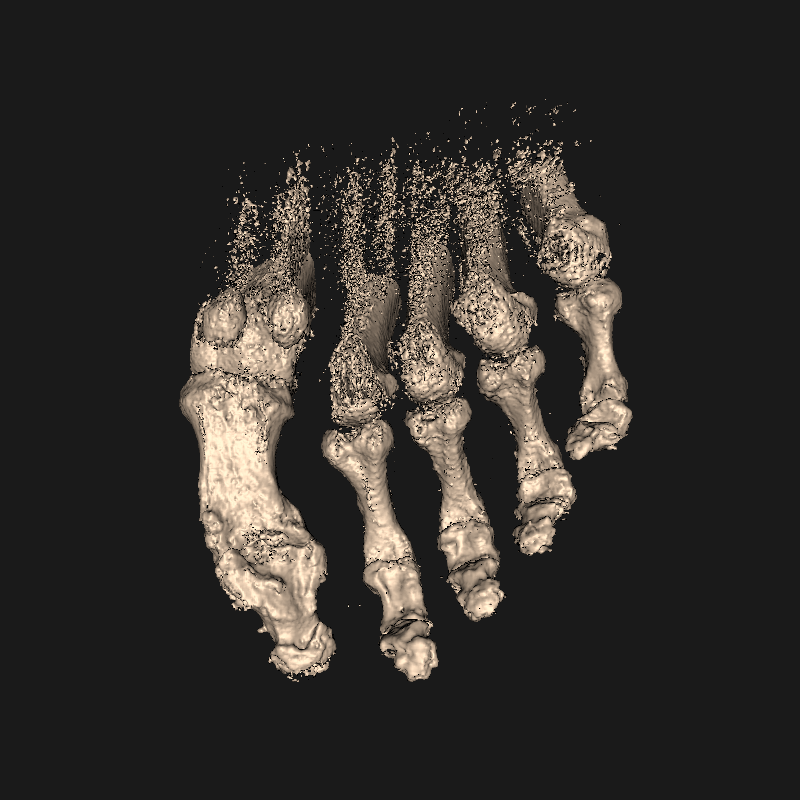

=== Iteration 2/20 ===
Visual diagnosis:
The current view shows the foot bones from an oblique top-down angle. The toes are visible at the bottom, and the ankle/heel region is at the top. However, the view is not directly from above - it's still at an angle showing some side perspective. Comparing to the target image which shows a cleaner top-down view, I need to continue moving the camera to look more directly down on the foot.

Reasoning:
The action history shows multiple ELEVATION_UP_COARSE moves and a ROLL_CW_90. To achieve a true top view, I need to continue elevating the camera upward to get a more orthogonal view looking straight down. The current view still has too much oblique angle. Since we're getting closer but not quite there, another elevation adjustment is needed.

Next action:
ELEVATION_UP_COARSE

Expected visual change:
The camera will orbit 45 degrees upward, bringing the viewpoint closer to directly above the foot. This should flatten the perspective further, making 

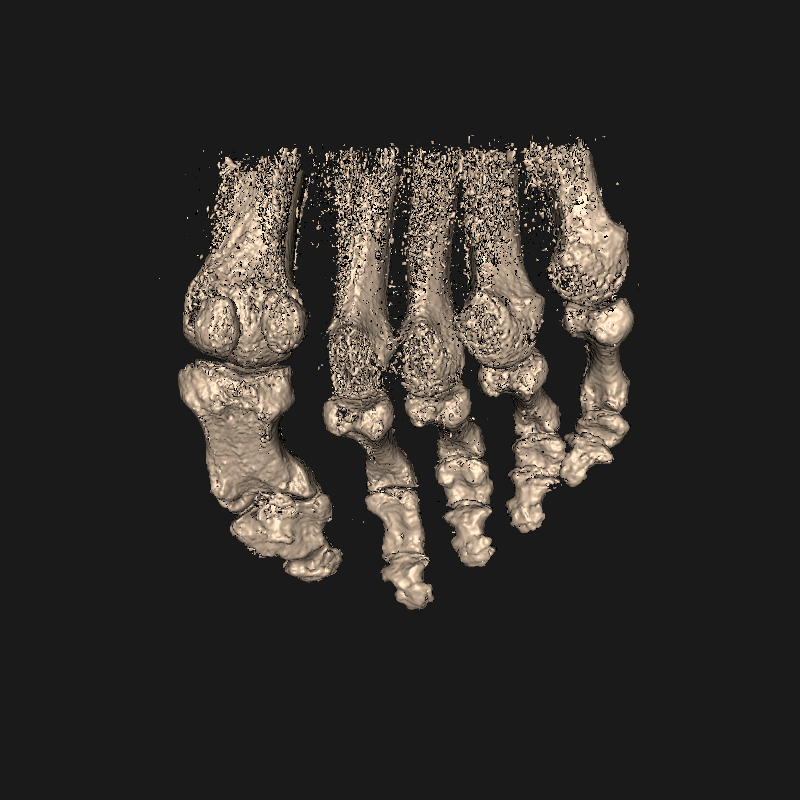

=== Iteration 3/20 ===


KeyboardInterrupt: 

In [6]:
from camera_reasoning.spatial_knowledge import extract_diagnosis_sections
from camera_reasoning.image_view_matcher import ImageViewMatcher
from camera_reasoning.text_view_matcher import TextViewMatcher
from camera_reasoning.frozen_reference_alignment import verify_observation_against_embeddings

# Built once, reused every iteration below — only the query (current screenshot /
# current observation text) gets re-encoded per iteration, not the reference database.
image_matcher = ImageViewMatcher(reference_dir="../reference_views", cache_path="../reference_embeddings.pkl")
image_matcher.build_index()
text_matcher = TextViewMatcher(descriptions_path="../reference_views/view_descriptions.json", cache_path="../reference_text_embeddings.pkl")
text_matcher.build_index()

num_iterations = 20

for i in range(num_iterations):
    print(f"=== Iteration {i + 1}/{num_iterations} ===", flush=True)

    # Capture the screenshot path BEFORE applying any action this iteration —
    # process_chatgpt_response() below re-renders and overwrites latest.png, so
    # verification must run first, against the exact same image the model saw
    # (and described in its "Visual observation"), not the post-rotation result.
    current_image_path = "../output/screenshots/latest.png"

    response = session.ask_chatgpt()
    print(response, flush=True)

    observation_text = extract_diagnosis_sections(response).get("visual_observation")
    if observation_text:
        verification = verify_observation_against_embeddings(
            current_image_path, observation_text, image_matcher, text_matcher, top_k=5
        )
        print("Top-3 similar image views (BEFORE this iteration's camera action):", flush=True)
        for m in verification["image_top_k"][:3]:
            print(f"    {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}", flush=True)
        print("Top-3 similar description views:", flush=True)
        for m in verification["text_top_k"][:3]:
            print(f"    {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}", flush=True)
    else:
        print("No 'Visual observation' section found in response; skipping verification.", flush=True)

    # NOW apply the action — this re-renders and overwrites latest.png with the new view.
    action = session.process_chatgpt_response(response)

    display(Image("../output/screenshots/latest.png"))
    if action == "STOP":
        break

## Experiment with a Custom Prompt

1. Start from the auto-generated prompt (or write your own from scratch).
2. Edit `custom_prompt` however you like — reword the rules, add few-shot examples, change the target description, etc.
3. Run the next cell to send it and see the raw reply, without applying anything yet.
4. If you're happy with the result, run the final cell to apply the returned action.

In [ ]:
# Start from the auto-generated prompt, then edit freely.
custom_prompt = session.write_llm_prompt()
print(custom_prompt)

In [ ]:
# Edit custom_prompt above (or reassign it directly here), then send it without applying the result.
response = session.ask_chatgpt(prompt=custom_prompt)
print(response)

In [ ]:
# Happy with the response? Apply it.
session.process_chatgpt_response(response)

display(Image("../output/screenshots/latest.png"))

## Frozen-Reference-Embedding Alignment (Experimental)

An alternative to the text-based loop above. Instead of reasoning from scratch every
iteration, it:
1. Picks the single most visually similar reference view **once**, via image
   embeddings (`reference_views/`), and freezes it as the alignment target.
2. Every iteration: the LLM describes the current screenshot and compares it against
   that same frozen target (never re-picks a new target), then chooses a camera action.
3. Also cross-checks the LLM's own description against the reference database via
   both image embeddings and text embeddings — printing the top-3 matches (with
   scores) from each, every iteration, so you can spot when the LLM's words disagree
   with what the embeddings say.

Requires `reference_views/` + `reference_views/view_descriptions.json` to already
exist (see `examples/generate_reference_views.py` and
`camera_reasoning/view_description_generator.py` if you haven't generated them yet).

In [ ]:
from camera_reasoning.frozen_reference_alignment import run_camera_reasoning_pipeline

result = run_camera_reasoning_pipeline(
    session,
    num_iterations=5,
    use_frozen_reference_alignment=True,
    references_dir="../reference_views",
    dry_run=False,  # set True to freeze the target + analyze/reason once WITHOUT moving the camera
)

display(Image("../output/screenshots/latest.png"))
print("\nFrozen target view:", result["alignment_target_reference"]["view_name"])
print("Applied actions:", result["applied_actions"])

---
## Utilities

In [ ]:
# Manually apply an action without calling the OpenAI API
# session.process_chatgpt_response("Next action:\nAZIMUTH_RIGHT_MEDIUM")

# Or paste a ChatGPT reply you already have (e.g. from the web UI) and process it directly:
# chatgpt_response = """Next action:\nAZIMUTH_RIGHT_MEDIUM"""
# session.process_chatgpt_response(chatgpt_response)

In [ ]:
# Hard-reset the camera (destroys manual alignment)
# session.reset_camera()
# session.render_and_save()
# display(Image("../output/screenshots/latest.png"))

In [ ]:
# Restore camera from a saved state
# session.load_camera_state("../output/camera_states/step_003_ELEVATION_UP_MEDIUM.json")